In [1]:
user = r"\SagixOffice"  # HomeOffice
#user = r"\vie43sq"
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import numpy as np
import src.fluorophore_systems as fs
import src.figures as fi
import src.distributions as d

%load_ext autoreload
%autoreload 2

# Binned photon counts 
Intensity distributions based on different photon count bin sizes

### 1 fluorophore, S0 S1 T1 system

In [2]:
rate_dict = dict(k_S0_S1=[7e6, "excitation"],
                 k_S1_S0=[1e9, "emission"],
                 k_S1_T1=[1e6, "intersystem crossing"],
                 k_T1_S0=[5e5, "triplet deexcitation"])

In [3]:
system = fs.GeneralModel(number=1, distances=1, rates=rate_dict)

In [4]:
system.simulate(n_steps=10000000, seed=99)

In [5]:
system.process()

### State lifetimes

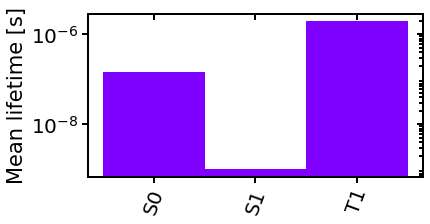

In [21]:
fig, ax = fi.FigureCollection(system).lifetimes(mode="single_states", statistic="mean")

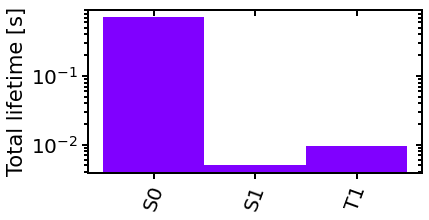

In [22]:
fig, ax = fi.FigureCollection(system).lifetimes(mode="single_states", statistic="total")

### State occurrences

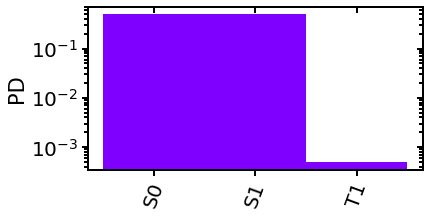

In [24]:
fig, ax = fi.FigureCollection(system).populations(mode="single_states", single_fluorophores=True,
                                                  bins=np.arange(0, 4)-0.5)

## 0.1 µs

In [6]:
system.emitters(unit="s", resample="0.1us", photon_collection=0.1)

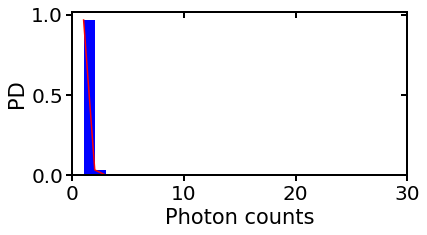

In [7]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=3,
                                                      xlim=[0, 30], pois=True)

## 1 µs

In [8]:
system.emitters(unit="s", resample="1us", photon_collection=0.1)

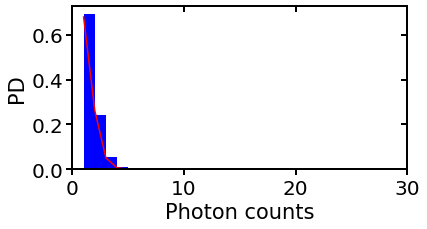

In [9]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=7,
                                                      xlim=[0, 30], pois=True)

## 10 µs

In [27]:
system.emitters(resample="10us", photon_collection=1)

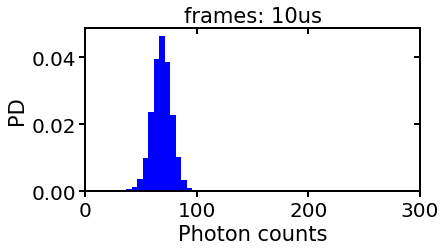

In [30]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=21,
                                                      xlim=[0, 300])#, pois=True)
#fig.savefig(r'C:\Users\SagixOffice\OneDrive - Universität Würzburg\Notebooks, plots\Plots\10µs_S0_S1_T1', bbox_inches='tight')

## 0.1 ms

In [6]:
system.emitters(resample="0.1ms", photon_collection=1)

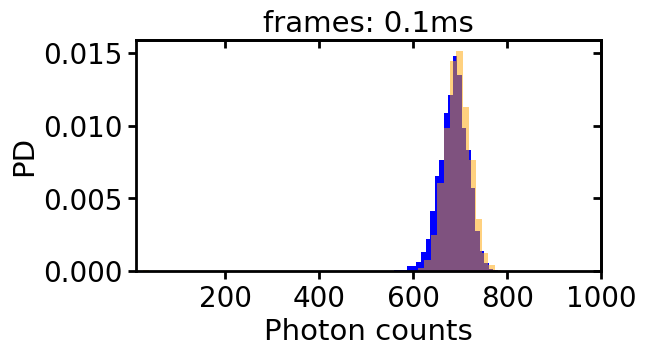

In [27]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=50,
                                                      xlim=[10, 1000])#, pois=True)

## 1 ms

In [14]:
system.emitters(unit="s", resample="1ms", photon_collection=0.1)

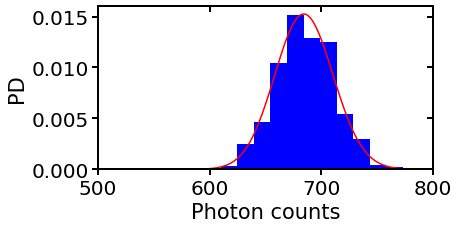

In [15]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=50,
                                                      xlim=[500, 800], pois=True)

## 10 ms

In [26]:
system.emitters(unit="s", resample="10ms", photon_collection=0.1)

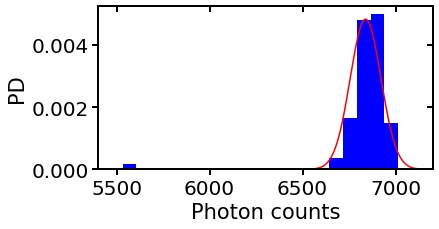

In [27]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False, bins=20,
                                                      xlim=[5400, 7200], pois=True)

In [90]:
system.fcs(log=True, normalize=True, deltat=1e-1, m=30)

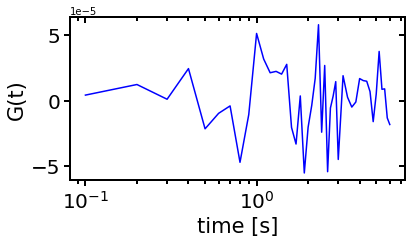

In [91]:
fig, ax = fi.FigureCollection(system).fcs()

In [92]:
system.fcs(log=False, normalize=True, deltat=1e-1, m=30)

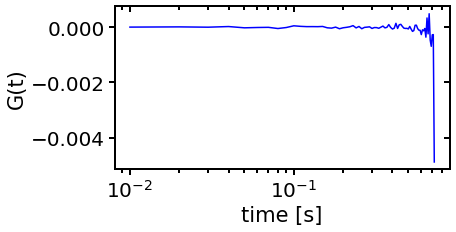

In [93]:
fig, ax = fi.FigureCollection(system).fcs()

In [94]:
system.fcs(log=True, normalize=True, deltat=1e-1, m=30)

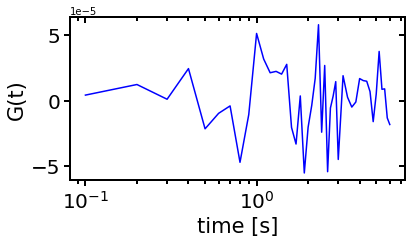

In [95]:
fig, ax = fi.FigureCollection(system).fcs()

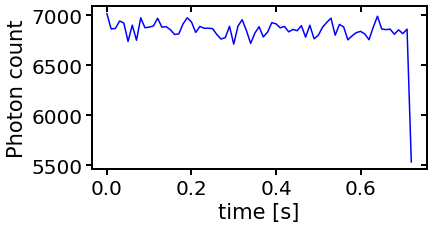

In [23]:
fig, ax = fi.FigureCollection(system).emission_events()